### Project 1 --> BMW Sales Prediction ::::: A Classification Project

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df=pd.read_csv('BMW_Car_Sales_Classification.csv')

In [6]:
df

,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume,Sales_Classification
0,5 Series,2016,Asia,Red,Petrol,Manual,3.5,151748,98740,8300,High
1,i8,2013,North America,Red,Hybrid,Automatic,1.6,121671,79219,3428,Low
2,5 Series,2022,North America,Blue,Petrol,Automatic,4.5,10991,113265,6994,Low
3,X3,2024,Middle East,Blue,Petrol,Automatic,1.7,27255,60971,4047,Low
4,7 Series,2020,South America,Black,Diesel,Manual,2.1,122131,49898,3080,Low
...,...,...,...,...,...,...,...,...,...,...,...
49995,i3,2014,Asia,Red,Hybrid,Manual,4.6,151030,42932,8182,High
49996,i3,2023,Middle East,Silver,Electric,Manual,4.2,147396,48714,9816,High
49997,5 Series,2010,Middle East,Red,Petrol,Automatic,4.5,174939,46126,8280,High
49998,i3,2020,Asia,White,Electric,Automatic,3.8,3379,58566,9486,High


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Model                 50000 non-null  object 
 1   Year                  50000 non-null  int64  
 2   Region                50000 non-null  object 
 3   Color                 50000 non-null  object 
 4   Fuel_Type             50000 non-null  object 
 5   Transmission          50000 non-null  object 
 6   Engine_Size_L         50000 non-null  float64
 7   Mileage_KM            50000 non-null  int64  
 8   Price_USD             50000 non-null  int64  
 9   Sales_Volume          50000 non-null  int64  
 10  Sales_Classification  50000 non-null  object 
dtypes: float64(1), int64(4), object(6)
memory usage: 4.2+ MB


In [8]:
df.describe()

,Year,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,2017.015700,3.247180,100307.203140,75034.600900,5067.514680
std,4.324459,1.009078,57941.509344,25998.248882,2856.767125
min,2010.000000,1.500000,3.000000,30000.000000,100.000000
25%,2013.000000,2.400000,50178.000000,52434.750000,2588.000000
50%,2017.000000,3.200000,100388.500000,75011.500000,5087.000000
75%,2021.000000,4.100000,150630.250000,97628.250000,7537.250000
max,2024.000000,5.000000,199996.000000,119998.000000,9999.000000


In [9]:
df.duplicated().sum()

0

In [11]:
df.head(2)

,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume,Sales_Classification
0,5 Series,2016,Asia,Red,Petrol,Manual,3.5,151748,98740,8300,High
1,i8,2013,North America,Red,Hybrid,Automatic,1.6,121671,79219,3428,Low


In [13]:
df['Sales_Classification'].value_counts()

Sales_Classification
Low     34754
High    15246
Name: count, dtype: int64

In [14]:
# if data is skewed toward one category so we use smote technique

In [15]:
df.head(2)

,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume,Sales_Classification
0,5 Series,2016,Asia,Red,Petrol,Manual,3.5,151748,98740,8300,High
1,i8,2013,North America,Red,Hybrid,Automatic,1.6,121671,79219,3428,Low


In [16]:
df.groupby('Year')['Sales_Classification'].value_counts()

Year  Sales_Classification
2010  Low                     2312
      High                    1018
2011  Low                     2260
      High                    1018
2012  Low                     2344
      High                     988
2013  Low                     2322
      High                    1004
2014  Low                     2345
      High                    1005
2015  Low                     2337
      High                    1021
2016  Low                     2364
      High                    1001
2017  Low                     2291
      High                     999
2018  Low                     2290
      High                     988
2019  Low                     2343
      High                    1049
2020  Low                     2215
      High                     990
2021  Low                     2381
      High                     991
2022  Low                     2355
      High                    1123
2023  Low                     2251
      High                  

In [17]:
df.drop('Year',axis=1,inplace=True)

In [18]:
X=df.drop('Sales_Classification',axis=1) # axis =0 remove all rows
y=df['Sales_Classification']

In [19]:
X.shape

(50000, 9)

In [20]:
y.shape

(50000,)

In [21]:
X.head()

,Model,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume
0,5 Series,Asia,Red,Petrol,Manual,3.5,151748,98740,8300
1,i8,North America,Red,Hybrid,Automatic,1.6,121671,79219,3428
2,5 Series,North America,Blue,Petrol,Automatic,4.5,10991,113265,6994
3,X3,Middle East,Blue,Petrol,Automatic,1.7,27255,60971,4047
4,7 Series,South America,Black,Diesel,Manual,2.1,122131,49898,3080


In [ ]:
# one hot encoding

#         Red    Blue   black
# Blue    0       1        0   
# Black   0        0       1
# red     1       0        0
# red
# black

In [ ]:
# label Encoding  we apply on lables or ouputs

# Heigh   0
# Low     1
# green   2

In [ ]:
num = X.select_dtypes(exclude='O').columns
cat = X.select_dtypes(include='O').columns

In [26]:
X.head()

,Model,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume
0,5 Series,Asia,Red,Petrol,Manual,3.5,151748,98740,8300
1,i8,North America,Red,Hybrid,Automatic,1.6,121671,79219,3428
2,5 Series,North America,Blue,Petrol,Automatic,4.5,10991,113265,6994
3,X3,Middle East,Blue,Petrol,Automatic,1.7,27255,60971,4047
4,7 Series,South America,Black,Diesel,Manual,2.1,122131,49898,3080


In [27]:
# Standard Scaling mean=0 , std=1

In [28]:
#One hot encoding ,label ,standard scaling

In [32]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,train_size=0.85,random_state=42)

In [ ]:
from sklearn.preprocessing import StandardScaler,OneHotEncoder, LabelEncoder
# standardization -> num
# Onehot          -> Cat
# Label           -> y

In [33]:
from sklearn.compose import make_column_transformer

label = LabelEncoder()

y_train = label.fit_transform(y_train)

In [34]:
y_train

array([1, 0, 1, ..., 1, 1, 1])

In [ ]:
y_test=label.transform(y_test)

In [38]:
y_test

array([1, 1, 1, ..., 0, 1, 1])

In [40]:
from sklearn.compose import make_column_transformer

transformer = make_column_transformer(
    (OneHotEncoder(),cat),
    (StandardScaler(),num)
)

In [41]:
X_train=transformer.fit_transform(X_train).toarray()

In [42]:
X_train

array([[ 0.        ,  0.        ,  0.        , ...,  1.44313346,
        -0.15621202,  0.19048917],
       [ 0.        ,  0.        ,  0.        , ...,  0.53425361,
        -1.17710493,  1.6926665 ],
       [ 0.        ,  0.        ,  0.        , ..., -0.69105709,
        -1.36345656, -0.81598014],
       ...,
       [ 0.        ,  0.        ,  0.        , ...,  0.72822071,
         1.73039622, -0.17218985],
       [ 0.        ,  0.        ,  0.        , ...,  0.17815238,
         1.24858372, -0.00205278],
       [ 0.        ,  0.        ,  0.        , ..., -1.01197632,
         0.31116804,  0.29271145]])

In [43]:
X_train=pd.DataFrame(X_train)

In [44]:
X_train.head()

,0,1,2,3,4,5,6,7,8,9,...,23,24,25,26,27,28,29,30,31,32
0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,1.336325,1.443133,-0.156212,0.190489
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.742533,0.534254,-1.177105,1.692666
2,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.841498,-0.691057,-1.363457,-0.815980
3,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.841498,-0.002643,0.561754,1.288678
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.643568,-0.111762,-1.294104,0.602179


In [46]:
X_test=transformer.transform(X_test)

In [48]:
X_test=pd.DataFrame(X_test.toarray())
X_test.tail()

,0,1,2,3,4,5,6,7,8,9,...,23,24,25,26,27,28,29,30,31,32
7495,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,-1.731599,-1.366041,1.016087,1.087735
7496,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.544602,-0.398449,-1.133346,-0.605234
7497,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,1.732186,1.012214,1.560170,1.127293
7498,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,-0.247120,1.244937,-0.122421,0.640687
7499,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,1.138394,-1.482842,-1.035667,-1.556391


In [49]:
from sklearn.linear_model import LogisticRegression

log=LogisticRegression()

In [50]:
log.fit(X_train,y_train)

LogisticRegression()

In [51]:
y_pred=log.predict(X_test)

In [52]:
y_pred

array([1, 1, 1, ..., 0, 1, 1])

In [54]:
from sklearn.metrics import accuracy_score,confusion_matrix


In [55]:
acc=accuracy_score(y_test,y_pred)
acc

0.9993333333333333

In [56]:
mat=confusion_matrix(y_test,y_pred)
mat

array([[2267,    3],
       [   2, 5228]])

In [ ]:
from sklearn.ensemble import RandomForestClassifier

random=RandomForestClassifier()

random.fit(X_train,y_train)

y_pred=random.predict(X_test)

acc=accuracy_score(y_test,y_pred)

acc

1.0

### Gal Stone Prediction 

In [59]:
df=pd.read_csv('dataset-uci.csv')
df.head()

,Gallstone Status,Age,Gender,Comorbidity,Coronary Artery Disease (CAD),Hypothyroidism,Hyperlipidemia,Diabetes Mellitus (DM),Height,Weight,...,High Density Lipoprotein (HDL),Triglyceride,Aspartat Aminotransferaz (AST),Alanin Aminotransferaz (ALT),Alkaline Phosphatase (ALP),Creatinine,Glomerular Filtration Rate (GFR),C-Reactive Protein (CRP),Hemoglobin (HGB),Vitamin D
0,0,50,0,0,0,0,0,0,185,92.8,...,40.0,134.0,20.0,22.0,87.0,0.82,112.47,0.0,16.0,33.0
1,0,47,0,1,0,0,0,0,176,94.5,...,43.0,103.0,14.0,13.0,46.0,0.87,107.10,0.0,14.4,25.0
2,0,61,0,0,0,0,0,0,171,91.1,...,43.0,69.0,18.0,14.0,66.0,1.25,65.51,0.0,16.2,30.2
3,0,41,0,0,0,0,0,0,168,67.7,...,59.0,53.0,20.0,12.0,34.0,1.02,94.10,0.0,15.4,35.4
4,0,42,0,0,0,0,0,0,178,89.6,...,30.0,326.0,27.0,54.0,71.0,0.82,112.47,0.0,16.8,40.6


In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 319 entries, 0 to 318
Data columns (total 39 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Gallstone Status                                319 non-null    int64  
 1   Age                                             319 non-null    int64  
 2   Gender                                          319 non-null    int64  
 3   Comorbidity                                     319 non-null    int64  
 4   Coronary Artery Disease (CAD)                   319 non-null    int64  
 5   Hypothyroidism                                  319 non-null    int64  
 6   Hyperlipidemia                                  319 non-null    int64  
 7   Diabetes Mellitus (DM)                          319 non-null    int64  
 8   Height                                          319 non-null    int64  
 9   Weight                                     

In [63]:
df.duplicated().sum()

0

In [64]:
df.describe()

,Gallstone Status,Age,Gender,Comorbidity,Coronary Artery Disease (CAD),Hypothyroidism,Hyperlipidemia,Diabetes Mellitus (DM),Height,Weight,...,High Density Lipoprotein (HDL),Triglyceride,Aspartat Aminotransferaz (AST),Alanin Aminotransferaz (ALT),Alkaline Phosphatase (ALP),Creatinine,Glomerular Filtration Rate (GFR),C-Reactive Protein (CRP),Hemoglobin (HGB),Vitamin D
count,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000,319.00000,319.000000,...,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000,319.000000
mean,0.495298,48.068966,0.492163,0.335423,0.037618,0.028213,0.025078,0.134796,167.15674,80.564890,...,49.475549,144.502163,21.684953,26.855799,73.112539,0.800611,100.818903,1.853856,14.418182,21.401411
std,0.500763,12.114558,0.500724,0.517340,0.190568,0.165841,0.156609,0.342042,10.05303,15.709069,...,17.718701,97.904493,16.697605,27.884413,24.181069,0.176433,16.971396,4.989591,1.775815,9.981659
min,0.000000,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,145.00000,42.900000,...,25.000000,1.390000,8.000000,3.000000,7.000000,0.460000,10.600000,0.000000,8.500000,3.500000
25%,0.000000,38.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,159.50000,69.600000,...,40.000000,83.000000,15.000000,14.250000,58.000000,0.650000,94.170000,0.000000,13.300000,13.250000
50%,0.000000,49.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,168.00000,78.800000,...,46.500000,119.000000,18.000000,19.000000,71.000000,0.790000,104.000000,0.215000,14.400000,22.000000
75%,1.000000,56.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,175.00000,91.250000,...,56.000000,172.000000,23.000000,30.000000,86.000000,0.920000,110.745000,1.615000,15.700000,28.060000
max,1.000000,96.000000,1.000000,3.000000,1.000000,1.000000,1.000000,1.000000,191.00000,143.500000,...,273.000000,838.000000,195.000000,372.000000,197.000000,1.460000,132.000000,43.400000,18.800000,53.100000


In [65]:
df

,Gallstone Status,Age,Gender,Comorbidity,Coronary Artery Disease (CAD),Hypothyroidism,Hyperlipidemia,Diabetes Mellitus (DM),Height,Weight,...,High Density Lipoprotein (HDL),Triglyceride,Aspartat Aminotransferaz (AST),Alanin Aminotransferaz (ALT),Alkaline Phosphatase (ALP),Creatinine,Glomerular Filtration Rate (GFR),C-Reactive Protein (CRP),Hemoglobin (HGB),Vitamin D
0,0,50,0,0,0,0,0,0,185,92.8,...,40.0,134.0,20.0,22.0,87.0,0.82,112.47,0.0,16.0,33.0
1,0,47,0,1,0,0,0,0,176,94.5,...,43.0,103.0,14.0,13.0,46.0,0.87,107.10,0.0,14.4,25.0
2,0,61,0,0,0,0,0,0,171,91.1,...,43.0,69.0,18.0,14.0,66.0,1.25,65.51,0.0,16.2,30.2
3,0,41,0,0,0,0,0,0,168,67.7,...,59.0,53.0,20.0,12.0,34.0,1.02,94.10,0.0,15.4,35.4
4,0,42,0,0,0,0,0,0,178,89.6,...,30.0,326.0,27.0,54.0,71.0,0.82,112.47,0.0,16.8,40.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
314,1,49,0,0,0,0,0,0,178,88.8,...,55.0,81.0,28.0,50.0,90.0,0.98,94.50,6.2,16.5,8.3
315,1,31,1,0,0,0,0,0,157,53.4,...,58.0,64.0,24.0,16.0,38.0,0.50,128.50,0.0,12.5,24.0
316,1,58,0,0,0,0,0,0,172,96.6,...,45.0,168.0,21.0,27.0,94.0,1.04,83.23,0.0,15.4,15.7
317,1,37,1,0,0,0,0,0,177,88.4,...,33.0,253.0,40.0,22.0,115.0,1.01,98.23,0.4,16.0,33.3


In [69]:
X=df.drop(columns=['Gallstone Status'],axis=1)
y=df['Gallstone Status']

In [70]:
y

0      0
1      0
2      0
3      0
4      0
      ..
314    1
315    1
316    1
317    1
318    1
Name: Gallstone Status, Length: 319, dtype: int64

In [71]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,train_size=0.8,random_state=42)

In [72]:
from sklearn.linear_model import LogisticRegression
from sklearn import svm
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier
from sklearn.metrics import accuracy_score,confusion_matrix

models={
    'LogisticRegression':LogisticRegression(),
    'Support_Vector_Machine':svm.SVC(),
    'GaussianNB':GaussianNB(),
    'KNeighborsClassifier':KNeighborsClassifier(),
    'DecisionTreeClassifier':DecisionTreeClassifier(),
    'RandomForestClassifier':RandomForestClassifier(),
    'AdaBoostClassifier':AdaBoostClassifier()
}

best_models={}

for i in range(len(models.values())):

    model=list(models.values())[i]
    model.fit(X_train,y_train)

    y_pred=model.predict(X_test)

    acc=accuracy_score(y_test,y_pred)
    conf=confusion_matrix(y_test,y_pred)

    name=list(models.keys())[i]

    print(f'----------------{name}----------------')
    print(f'Accuracy of model --> {acc}\n')
    print(f'Confussion Matrix is --> \n{conf}\n\n')
    if acc>0.80:
        best_models[name]=acc




/home/varun-kasnia/anaconda3/envs/dl/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


----------------LogisticRegression----------------
Accuracy of model --> 0.859375

Confussion Matrix is --> 
[[30  3]
 [ 6 25]]


----------------Support_Vector_Machine----------------
Accuracy of model --> 0.640625

Confussion Matrix is --> 
[[20 13]
 [10 21]]


----------------GaussianNB----------------
Accuracy of model --> 0.5625

Confussion Matrix is --> 
[[32  1]
 [27  4]]


----------------KNeighborsClassifier----------------
Accuracy of model --> 0.484375

Confussion Matrix is --> 
[[19 14]
 [19 12]]


----------------DecisionTreeClassifier----------------
Accuracy of model --> 0.71875

Confussion Matrix is --> 
[[25  8]
 [10 21]]


----------------RandomForestClassifier----------------
Accuracy of model --> 0.84375

Confussion Matrix is --> 
[[28  5]
 [ 5 26]]


----------------AdaBoostClassifier----------------
Accuracy of model --> 0.8125

Confussion Matrix is --> 
[[29  4]
 [ 8 23]]




### Un Supervised Learning

In [73]:
from sklearn.datasets import make_blobs

In [74]:
X,y=make_blobs(n_samples=999,centers=4,n_features=2)

In [75]:
X

array([[ -6.58098426,   3.79953078],
       [  2.38107933,  -8.19692656],
       [ -6.78492897,   6.04267654],
       ...,
       [ -5.47348675,   6.78045566],
       [  2.99027226, -10.89457439],
       [  8.53027135,   1.33271517]])

In [76]:
y

array([1, 3, 1, 3, 2, 0, 1, 3, 3, 3, 2, 1, 3, 3, 0, 3, 1, 2, 0, 1, 1, 0,
       1, 0, 3, 0, 3, 0, 1, 2, 0, 3, 0, 3, 3, 0, 2, 3, 2, 2, 1, 0, 0, 3,
       0, 1, 1, 3, 2, 2, 0, 0, 1, 2, 1, 3, 3, 2, 3, 2, 2, 3, 1, 1, 0, 1,
       1, 2, 2, 2, 1, 2, 2, 1, 0, 2, 2, 2, 0, 0, 3, 3, 0, 1, 3, 0, 0, 2,
       2, 1, 2, 3, 1, 1, 2, 0, 0, 0, 3, 3, 0, 2, 2, 0, 2, 3, 3, 1, 3, 3,
       0, 1, 3, 1, 2, 3, 0, 2, 3, 1, 1, 1, 3, 2, 3, 0, 1, 0, 3, 3, 1, 2,
       2, 2, 0, 2, 3, 0, 2, 0, 2, 3, 2, 1, 3, 0, 3, 3, 0, 0, 3, 3, 1, 3,
       1, 3, 2, 0, 2, 1, 2, 2, 3, 3, 0, 0, 3, 1, 3, 2, 2, 0, 2, 3, 3, 0,
       1, 3, 2, 2, 3, 0, 2, 0, 2, 0, 1, 0, 3, 0, 3, 0, 2, 3, 3, 2, 3, 3,
       0, 0, 3, 3, 2, 3, 1, 2, 0, 2, 2, 1, 2, 3, 0, 1, 3, 3, 2, 1, 1, 0,
       3, 2, 3, 1, 0, 1, 1, 0, 2, 0, 3, 1, 2, 3, 0, 3, 0, 1, 3, 3, 3, 1,
       3, 3, 1, 2, 1, 0, 0, 1, 0, 3, 1, 0, 2, 0, 3, 1, 1, 0, 2, 2, 1, 3,
       0, 2, 3, 0, 3, 3, 1, 0, 0, 2, 3, 0, 0, 0, 1, 1, 0, 2, 1, 1, 3, 0,
       1, 3, 1, 0, 1, 0, 2, 3, 1, 0, 2, 1, 2, 0, 0,

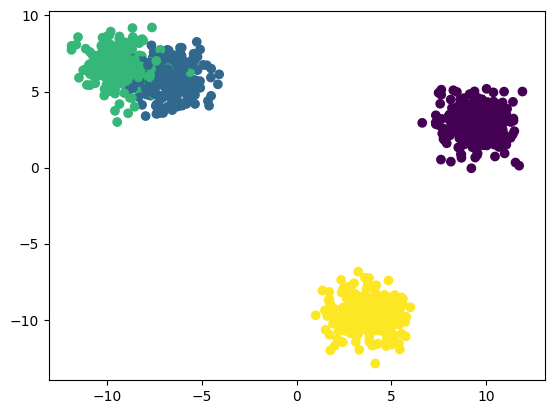

In [79]:
plt.scatter(X[:,0],X[:,1],c=y)

In [80]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,train_size=0.8,random_state=42)

In [82]:
from sklearn.cluster import KMeans

In [85]:
wcss=[]
for k in range(1,20):
    model=KMeans(n_clusters=k)
    model.fit(X_train)
    wcss.append(model.inertia_)

In [86]:
wcss

[83195.48322654939,
 21899.46302981558,
 2402.9829423428896,
 1515.0052980367946,
 1370.2733209021474,
 1232.8499582543038,
 1115.2408417079516,
 1011.2429451504703,
 966.1860787120459,
 840.6408216514834,
 767.2321363397724,
 736.3832409294671,
 623.4449283255096,
 597.1697519855966,
 569.6951415472153,
 540.3542479570115,
 518.9887266456611,
 473.6800032414855,
 450.700430840778]

([<matplotlib.axis.XTick at 0x795f27989010>,
 [Text(1, 0, '1'),
  Text(2, 0, '2'),
  Text(3, 0, '3'),
  Text(4, 0, '4'),
  Text(5, 0, '5'),
  Text(6, 0, '6'),
  Text(7, 0, '7'),
  Text(8, 0, '8'),
  Text(9, 0, '9'),
  Text(10, 0, '10'),
  Text(11, 0, '11'),
  Text(12, 0, '12'),
  Text(13, 0, '13'),
  Text(14, 0, '14'),
  Text(15, 0, '15'),
  Text(16, 0, '16'),
  Text(17, 0, '17'),
  Text(18, 0, '18'),
  Text(19, 0, '19')])

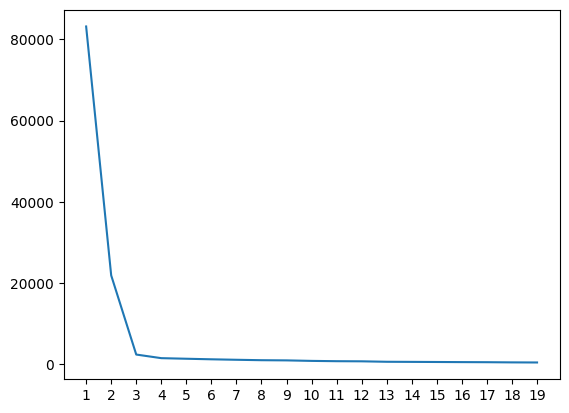

In [88]:
plt.plot(range(1,20),wcss)
plt.xticks(range(1,20))

In [90]:
final=KMeans(n_clusters=3)

DB SCAN

In [91]:
from sklearn.datasets import make_moons

In [92]:
X,y=make_moons(n_samples=999,noise=0.05)

In [93]:
X

array([[ 1.49005508, -0.38408558],
       [ 0.70150495,  0.76378855],
       [ 1.32984562, -0.48070361],
       ...,
       [ 1.84133   , -0.07457932],
       [ 0.07454407,  0.40579698],
       [ 1.30818159, -0.48362128]])

In [94]:
y

array([1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1,
       0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0,
       0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1,
       0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1,
       0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1,
       1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0,
       1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1,
       1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0,
       1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0,
       0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1,

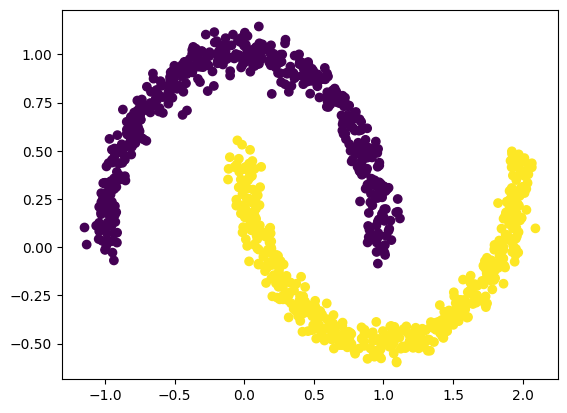

In [96]:
plt.scatter(X[:,0],X[:,1],c=y)

In [97]:
# home work try to do standard scalar on X

In [98]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,train_size=0.8,random_state=42)

In [99]:
from sklearn.cluster import DBSCAN

In [101]:
model=DBSCAN()

In [102]:
model.fit(X_train)

DBSCAN()

### Final Assignments
## 1 project Regression use all algos
## 1 Unsupervise learning use all algos

## submission at 8 pm start and close on 9 pm